<a href="https://colab.research.google.com/github/Mikolaj-13/lecture1/blob/main/klasyfikacja_binarna%20-%20por%C3%B3wnanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
y = data.target #list(data.target_names)
X = data.data #data.feature_names

1. Sprawdź liczbę wszystkich przypadków
2. Sprawdź liczbę przypadków raka złośliwego
3. Narysuj histogram średniego obszaru (mean area)
4. Narysuj wykres rozrzutu (scatterplot) średniego obszaru od klasyfikacji (użyj
sns.regplot)

In [6]:
X.shape

# 569 wszystkich przypadków

(569, 30)

In [7]:
sum(y)

# 357 przypadków złośliwych

np.int64(357)

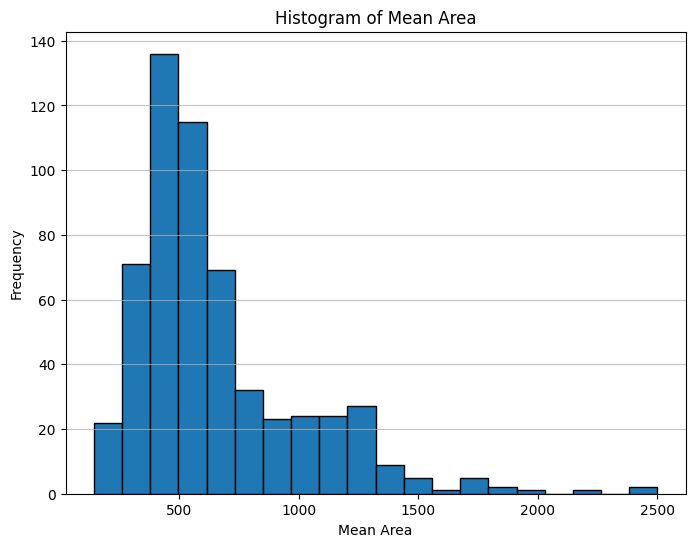

In [8]:
import matplotlib.pyplot as plt

mean_area_index = data.feature_names.tolist().index('mean area')

mean_area = X[:, mean_area_index]

plt.figure(figsize=(8, 6))
plt.hist(mean_area, bins=20, edgecolor='black')
plt.title('Histogram of Mean Area')
plt.xlabel('Mean Area')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

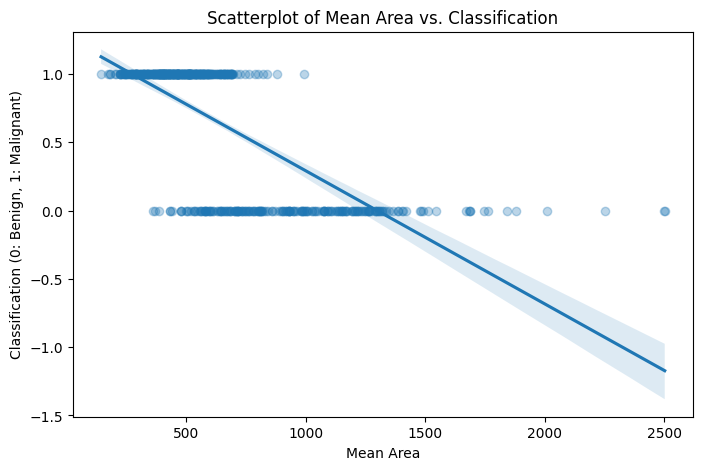

In [9]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({'Mean Area': mean_area, 'Classification': y})

plt.figure(figsize=(8, 5))
sns.regplot(x='Mean Area', y='Classification', data=df, scatter_kws={'alpha':0.3})
plt.title('Scatterplot of Mean Area vs. Classification')
plt.xlabel('Mean Area')
plt.ylabel('Classification (0: Benign, 1: Malignant)')
plt.show()

Zbuduj model regresji logistycznej
1. Sprawdź, jeśli dane nie są ustandaryzowane zrób to
2. Podziel zbiór danych na testowy (30%) i uczący (70%)
3. Zwizualizuj wyniki używając:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (398, 30)
Shape of X_test: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)


In [12]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=100)
model.fit(X_train, y_train)

LogisticRegression(random_state=100)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



<Figure size 800x600 with 0 Axes>

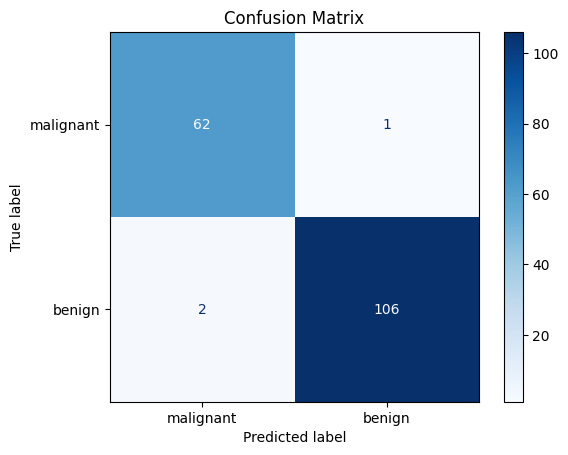

<Figure size 800x600 with 0 Axes>

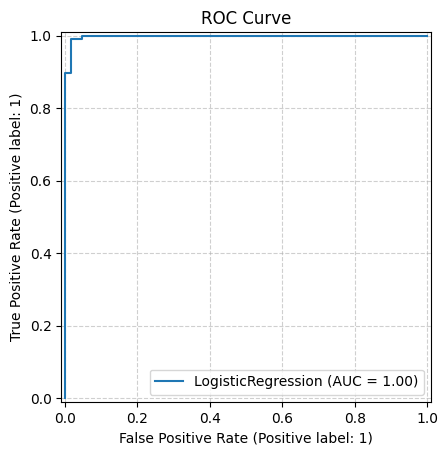

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



<Figure size 800x600 with 0 Axes>

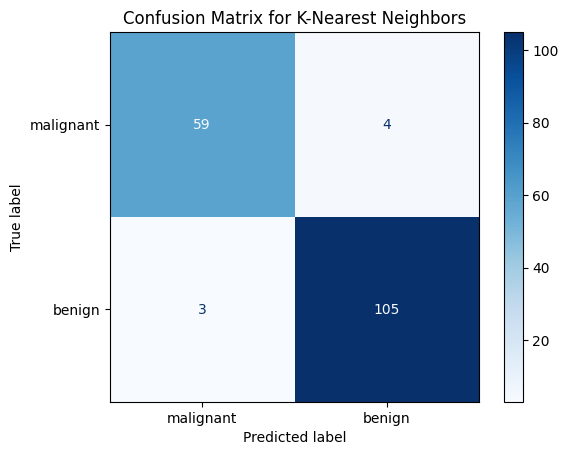

<Figure size 800x600 with 0 Axes>

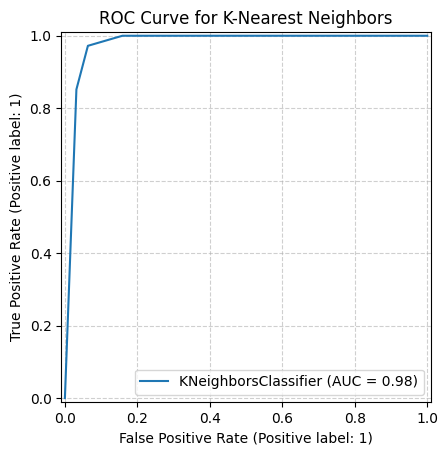

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for K-Nearest Neighbors')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(knn_model, X_test, y_test)
plt.title('ROC Curve for K-Nearest Neighbors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        63
           1       0.97      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



<Figure size 800x600 with 0 Axes>

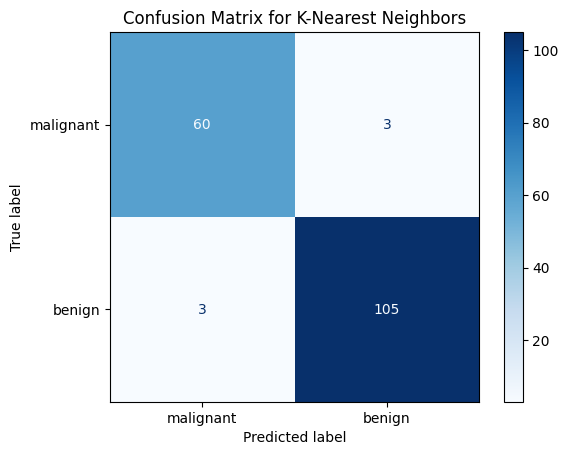

<Figure size 800x600 with 0 Axes>

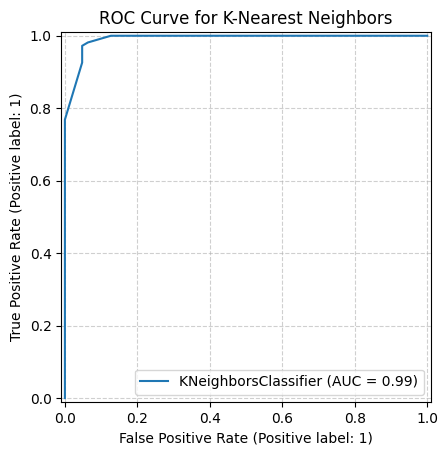

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=8)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_pred_proba_knn = knn_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for K-Nearest Neighbors')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(knn_model, X_test, y_test)
plt.title('ROC Curve for K-Nearest Neighbors')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



<Figure size 800x600 with 0 Axes>

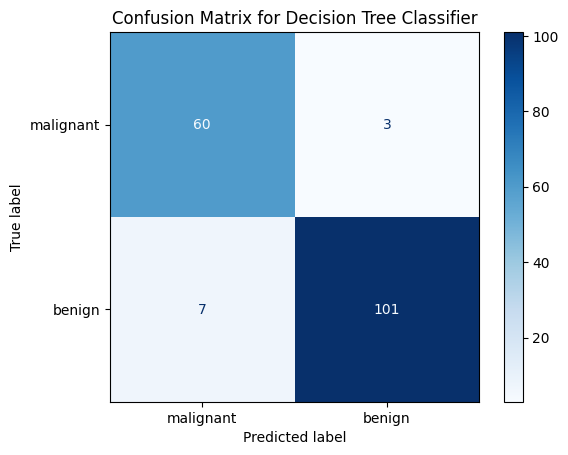

<Figure size 800x600 with 0 Axes>

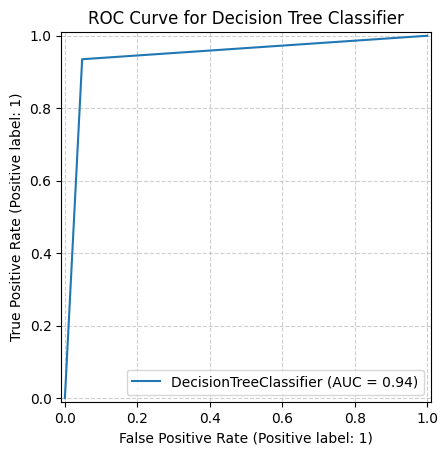

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

y_pred_dtc = dtc_model.predict(X_test)
y_pred_proba_dtc = dtc_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dtc))

cm_dtc = confusion_matrix(y_test, y_pred_dtc)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_dtc, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(dtc_model, X_test, y_test)
plt.title('ROC Curve for Decision Tree Classifier')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.94      0.95      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



<Figure size 800x600 with 0 Axes>

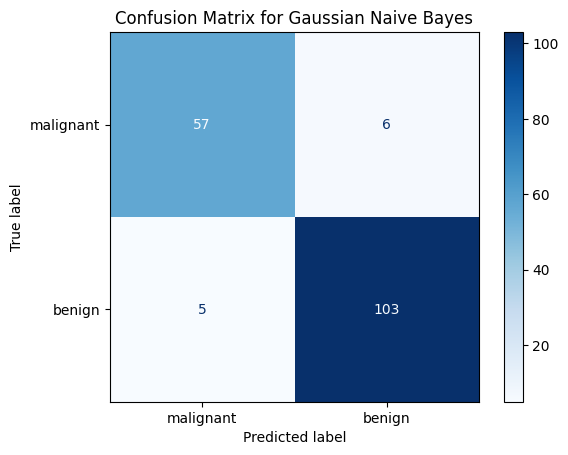

<Figure size 800x600 with 0 Axes>

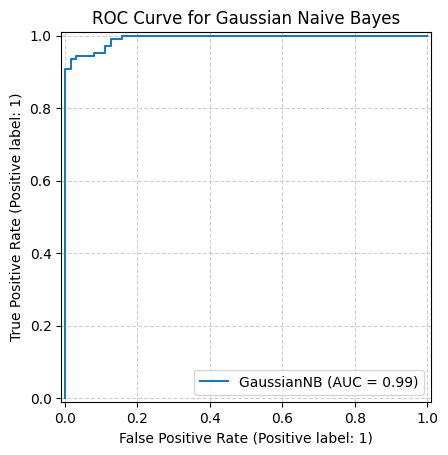

In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

y_pred_gnb = gnb_model.predict(X_test)
y_pred_proba_gnb = gnb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gnb))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(gnb_model, X_test, y_test)
plt.title('ROC Curve for Gaussian Naive Bayes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

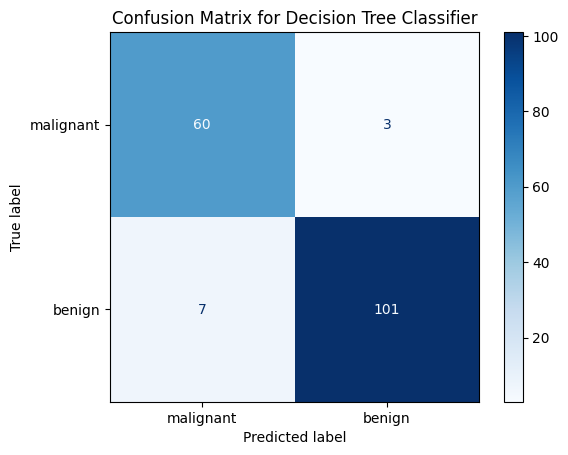

<Figure size 800x600 with 0 Axes>

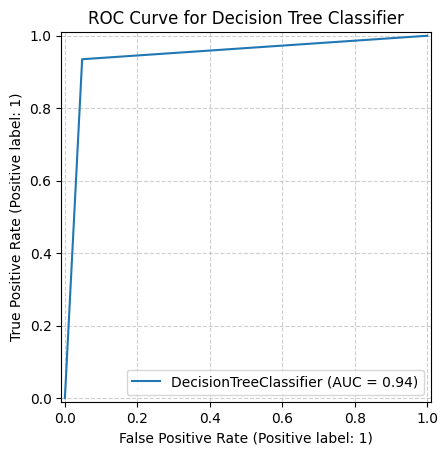

In [21]:
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_dtc, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(dtc_model, X_test, y_test)
plt.title('ROC Curve for Decision Tree Classifier')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



<Figure size 800x600 with 0 Axes>

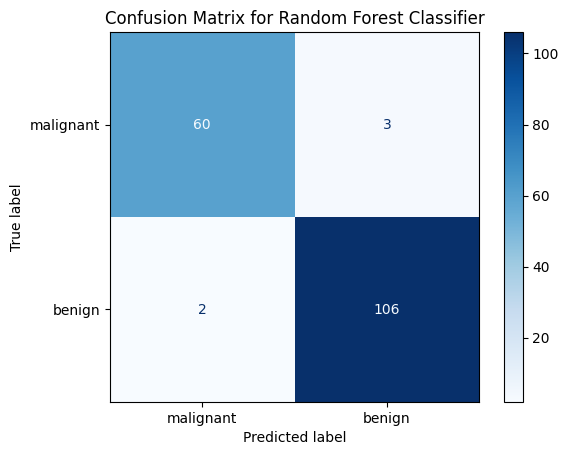

<Figure size 800x600 with 0 Axes>

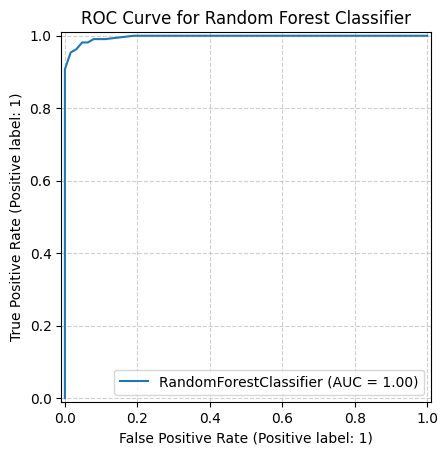

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, roc_curve, classification_report
import matplotlib.pyplot as plt

rfc_model = RandomForestClassifier(n_estimators=15, random_state=42)
rfc_model.fit(X_train, y_train)

y_pred_rfc = rfc_model.predict(X_test)
y_pred_proba_rfc = rfc_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rfc))

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
display_labels = data.target_names

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=display_labels).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rfc_model, X_test, y_test)
plt.title('ROC Curve for Random Forest Classifier')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Wizualizacja jednego z drzew w lesie losowym

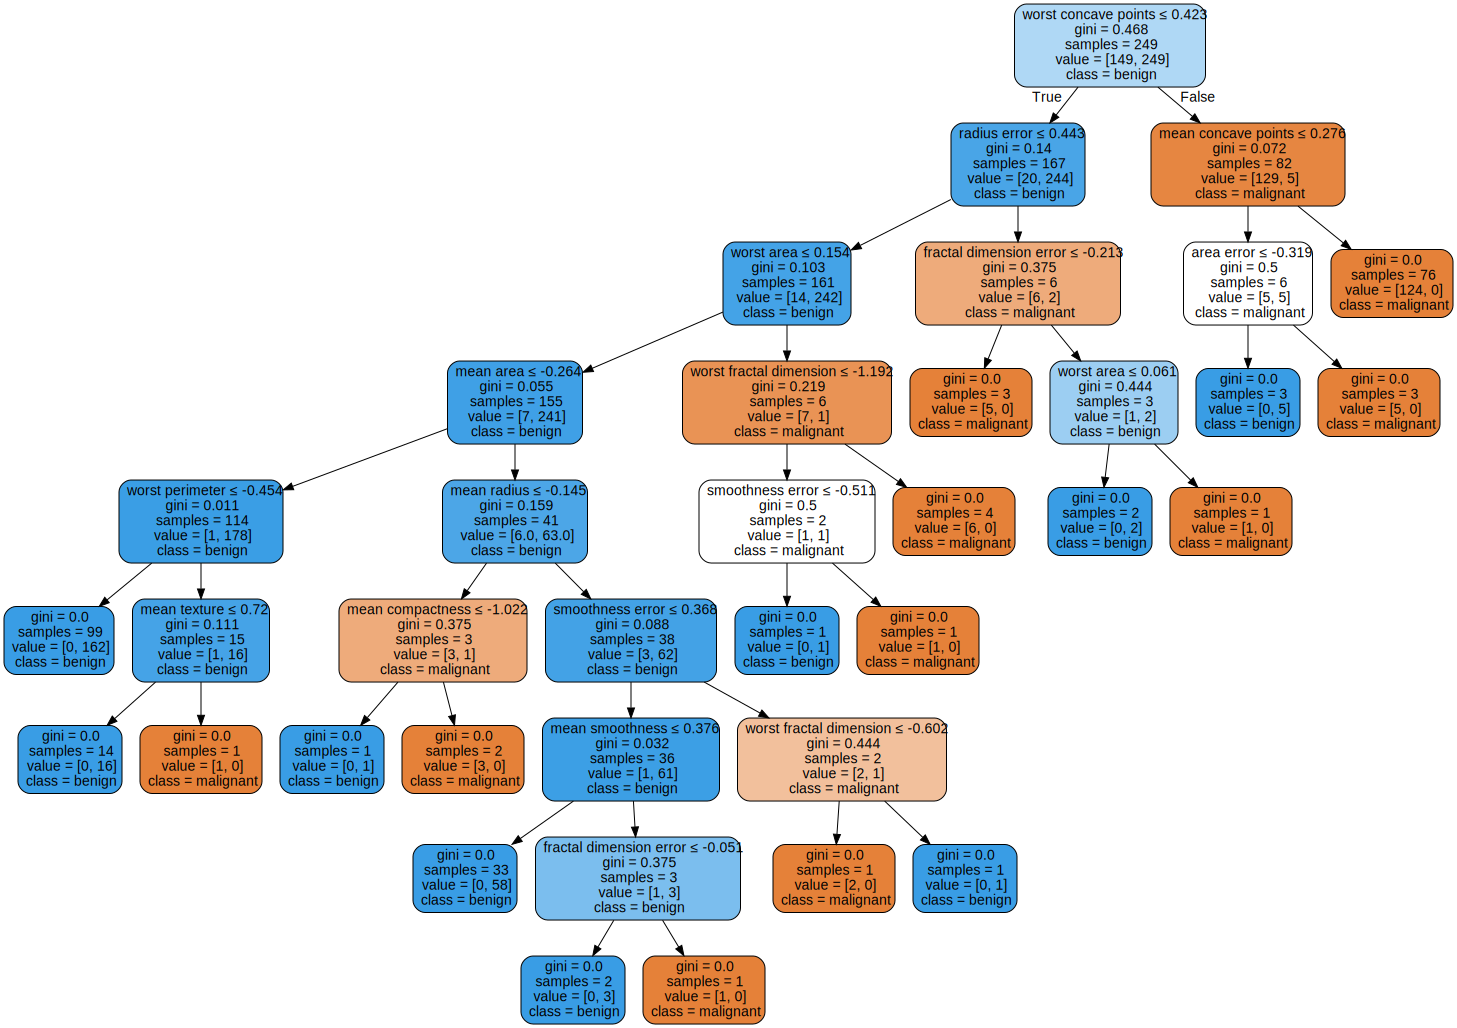

In [20]:
from sklearn.tree import export_graphviz
import graphviz

# Wybierz pierwsze drzewo z lasu losowego do wizualizacji
one_tree = rfc_model.estimators_[0]

# Eksportuj drzewo decyzyjne do formatu DOT
dot_data = export_graphviz(one_tree, out_file=None,
                           feature_names=data.feature_names,
                           class_names=data.target_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Renderuj graf
graph = graphviz.Source(dot_data)
graph.render('random_forest_tree', format='png', cleanup=True)
display(graph) # Wyświetl drzewo w notatniku

## Podsumowanie wyników klasyfikacji

Zastosowałem 5 klasyfikatorów. Oto ich wyniki:

*   Regresja Logistyczna: 98%
*   K-Najbliższych Sąsiadów: 96%
*   Las Losowy: 97%
*   Drzewo Decyzyjne: 94%
*   Naiwny Klasyfikator Bayesa: 94%

Wnioski:

Najlepszą skuteczność osiągnęła regresja ligistyczna z wynikiem 98%, co wskazuje na jej wysoką zdolność do prawidłowej klasyfikacji przypadków. Zaraz za nią plasuje się las losowy z 97%, a na trzecim miejscu KNN - 96%.